### **Exercícios de Regressão – Linear, Múltipla e Polinomial**


### 1. Regressão Linear Simples – Exercícios

**Exercício 1:**

Neste exercício, vamos gerar dados seguindo o modelo:

$$y = 3x + 2 + w,$$


onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e variância unitária.

O objetivo é ajustar um modelo de regressão linear e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.

---

**Exercício 2:**

Crie um conjunto de dados com $N = 100$ amostras seguindo o modelo:

$$y = \beta_0 + \beta_1 x + w,$$


onde:

- $x$ é um vetor coluna com $N$ elementos gerados a partir de uma distribuição **uniforme** no intervalo $[0, 10]$, representando os **anos de uso**;
- $\beta_0 = 50\,000$ é o preço inicial sem uso;
- $\beta_1 = -3\,000$ é a taxa de desvalorização por ano (relação linear decrescente);
- $w$ é um vetor coluna com $N$ elementos amostrados de uma **distribuição normal Gaussiana** com média zero e desvio padrão $\sigma = 2000$, representando ruído no preço.

Treine um modelo de regressão linear para estimar $\beta_0$ e $\beta_1$ e compare esses valores com os coeficientes reais. Plote a função original, os dados ruidosos e a reta estimada.

-----------------------------------------------------------
### 2. Regressão Linear Múltipla – Exercícios

**Exercício 3:**

Considere o modelo linear:

$$y = 5 + 3x_1 - 2x_2 + w,$$

onde:

- $x_1$ e $x_2$ são vetores coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é ajustar um modelo de regressão linear múltipla e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.

**Exercício 4:**

Neste exercício, vamos investigar o impacto da normalização quando trabalhamos com variáveis que possuem **escalas muito diferentes**.

Considere:

- $x_1$: variável na escala de **0 a 10**.  
- $x_2$: variável na escala de **0 a 10.000**.

O modelo real utilizado para gerar os dados será:

$$y = 4x_1 + 0.002x_2 + w,$$

onde o ruído $w$ segue uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 5$.

O objetivo é:

1. Treinar um **modelo sem normalização**.  
2. Treinar um **modelo com normalização via StandardScaler**.  
3. Comparar coeficientes e plotar a função original, os dados ruidosos e a reta estimada.  
4. Explicar por que a normalização impacta os coeficientes.

-----------------------------------------------------------
 ### 3. Regressão Polinomial – Exercícios

**Exercício 5:**
Considere o seguinte modelo gerador de dados:

$$
y = 2x^2 - x + 1 + w,
$$

onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é analisar o comportamento da regressão polinomial ao tentar aproximar um modelo não linear verdadeiro utilizando diferentes graus de complexidade.
Treine modelos de regressão polinomial considerando as seguintes hipóteses:

- Grau 1 (modelo linear):

$$
y \approx \beta_0 + \beta_1 x
$$

- Grau 2 (modelo correto em relação ao processo gerador):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2
$$

- Grau 3 (modelo superparametrizado):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3
$$

**Objetivo:**

Comparar o desempenho dos três modelos em termos de:

- capacidade de aproximação da função verdadeira;
- plotar a função original, os dados ruidosos e a reta estimada.
- impacto da complexidade do modelo (underfitting vs. overfitting);
- influência do termo de ruído $w$ na estimativa dos coeficientes.

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
np.random.seed(10)

###1.

In [31]:
x = np.random.uniform(-1,1,size=(1000,1))
w = np.random.randn(1000,1)
y = 3*x + 2
y_noisy = y + w

In [32]:
model = LinearRegression()
model.fit(x,y_noisy)
a_hat = model.coef_[0][0]
b_hat = model.intercept_[0]

print(f"a_hat: {a_hat:.3f}")
print(f"b_hat: {b_hat:.3f}")

a_hat: 3.015
b_hat: 1.981


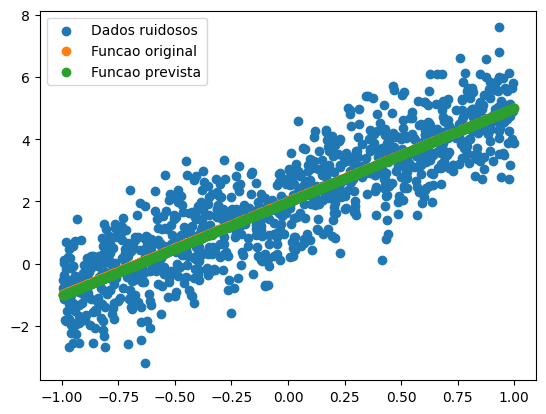

In [33]:
y_pred = model.predict(x)

plt.scatter(x,y_noisy,label='Dados ruidosos')
plt.scatter(x, y, label='Funcao original')
plt.scatter(x,y_pred,label='Funcao prevista')
plt.legend()
plt.show()

###2.

In [34]:
x = np.random.uniform(0,10,size=(100,1))
y = 50000 -3000*x
w = np.random.normal(loc=0,scale=2000,size=(100,1))
y_noisy = y + w

In [35]:
model = LinearRegression()
model.fit(x,y_noisy)
beta0 = model.intercept_[0]
beta1 = model.coef_[0][0]

print(f'beta0: {beta0}')
print(f'beta1: {beta1}')

beta0: 50410.20237606442
beta1: -3062.078811978925


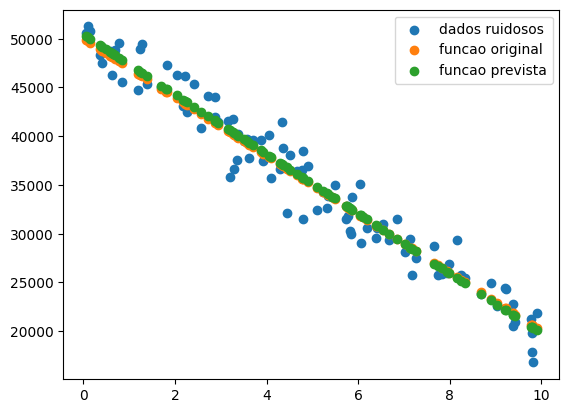

In [36]:
y_hat = model.predict(x)

plt.scatter(x,y_noisy,label='dados ruidosos')
plt.scatter(x,y,label='funcao original')
plt.scatter(x,y_hat,label='funcao prevista')
plt.legend()
plt.show()

###3.

In [46]:
x1 = np.random.uniform(-1,1,size=(1000,1))
x2 = np.random.uniform(-1,1,size=(1000,1))
w = np.random.normal(loc=0,scale=0.5,size=(1000,1))
y = 5 + 3*x1 - 2*x2
y_noisy = y + w

In [47]:
X = np.column_stack((x1,x2))
model = LinearRegression()
model.fit(X,y_noisy)
b = model.intercept_[0]
a1 = model.coef_[0][0]
a2 = model.coef_[0][1]

print(f'b={b}')
print(f'a1={a1}')
print(f'a2={a2}')

b=5.042226069504873
a1=3.0463837361647577
a2=-2.004826350526919


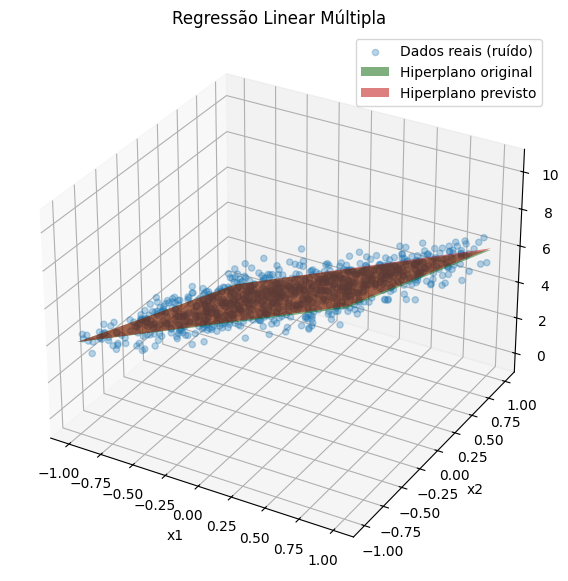

In [54]:
model.predict(X)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_noisy, alpha=0.3, label="Dados reais (ruído)")

# Criando um grid para o plano
x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(x1), max(x1), 40),
    np.linspace(min(x2), max(x2), 40))

# Plano previsto
y_grid = (b
    + a1 * x1_grid
    + a2 * x2_grid)

y_grid_original = (5 + 3*x1_grid - 2*x2_grid)

# Superfície do plano
ax.plot_surface(x1_grid, x2_grid, y_grid_original, alpha=0.5, color='green',label='Hiperplano original')
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5, color='red',label='Hiperplano previsto')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Regressão Linear Múltipla")
plt.legend()
plt.show()

###4.

In [91]:
x1 = np.random.uniform(0,10,size=(100,1))
x2 = np.random.uniform(0,10000,size=(100,1))
w = np.random.normal(loc=0,scale=5,size=(100,1))
y = 4*x1 + 0.002*x2
y_noisy = y+ w

In [92]:
X = np.column_stack((x1,x2))
model = LinearRegression()
model.fit(X,y_noisy)
a1 = model.coef_[0][0]
a2 = model.coef_[0][1]
b = model.intercept_[0]
print(f'a1:{a1}\na2:{a2}\nb:{b}')

a1:4.221754689823655
a2:0.002158438372906139
b:-2.35770630854422


In [93]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
model = LinearRegression()
model.fit(X,y_noisy)
a11 = model.coef_[0][0]
a22 = model.coef_[0][1]
b1 = model.intercept_[0]
print(f'a1:{a11}\na2:{a22}\nb:{b1}')

a1:12.89587124190872
a2:6.171931696708809
b:30.84234010792981


A normalização muda os coeficientes porque muda a escala de x. logo, para ter o mesmo hiperplano, devemos multiplicar esses novos coeficientes pelos valores de x após a transformação do StandardScaler()

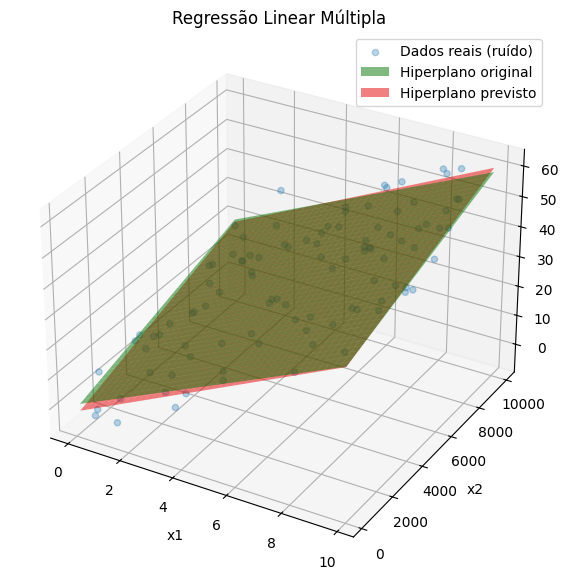

In [94]:
model.predict(X)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_noisy, alpha=0.3, label="Dados reais (ruído)")

# Criando um grid para o plano
x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(x1), max(x1), 40),
    np.linspace(min(x2), max(x2), 40))



# Plano previsto
y_grid = (b
    + a1 * x1_grid
    + a2 * x2_grid)

y_grid_original = 4*x1_grid + 0.002*x2_grid

# Superfície do plano
ax.plot_surface(x1_grid, x2_grid, y_grid_original, alpha=0.5, color='green',label='Hiperplano original')
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5, color='red',label='Hiperplano previsto')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Regressão Linear Múltipla")
plt.legend()
plt.show()

###5.

In [105]:
x = np.random.uniform(-1,1,(1000,1))
w = np.random.normal(loc=0,scale=.5,size=(1000,1))
y = 2*x**2 - x + 1
y_noisy = y + w

In [106]:
poly = PolynomialFeatures(degree=1, include_bias=True) # INCLUI O COEFICIENTE DE BIAS, O PONTO EM QUE A CURVA INTERCEPTA O EIXO Y (DESLOCA A CURVA)
X_poly = poly.fit_transform(x)
model = LinearRegression()
model.fit(X_poly, y_noisy)
y_pred_grau1 = model.predict(X_poly)

In [107]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(x)
model = LinearRegression()
model.fit(X_poly, y_noisy)
y_pred_grau2 = model.predict(X_poly)

In [116]:
poly = PolynomialFeatures(degree=3, include_bias=True) # INCLUI O COEFICIENTE DE BIAS, O PONTO EM QUE A CURVA INTERCEPTA O EIXO Y (DESLOCA A CURVA)
X_poly = poly.fit_transform(x)
model = LinearRegression()
model.fit(X_poly, y_noisy)
y_pred_grau3 = model.predict(X_poly)

In [121]:
poly = PolynomialFeatures(degree=100, include_bias=True) # INCLUI O COEFICIENTE DE BIAS, O PONTO EM QUE A CURVA INTERCEPTA O EIXO Y (DESLOCA A CURVA)
X_poly = poly.fit_transform(x)
model = LinearRegression()
model.fit(X_poly, y_noisy)
y_pred_grau100 = model.predict(X_poly)

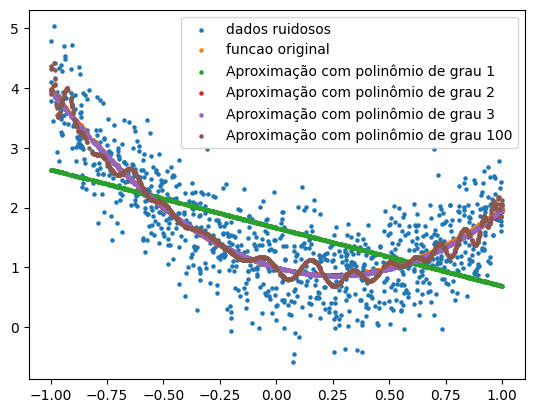

In [129]:
plt.scatter(x,y_noisy,label='dados ruidosos',s=5)
plt.scatter(x,y,label='funcao original',s=5)
plt.scatter(x,y_pred_grau1,label='Aproximação com polinômio de grau 1',s=5)
plt.scatter(x,y_pred_grau2,label='Aproximação com polinômio de grau 2',s=5)
plt.scatter(x,y_pred_grau3,label='Aproximação com polinômio de grau 3',s=5)
plt.scatter(x,y_pred_grau100,label='Aproximação com polinômio de grau 100',s=5)

plt.legend()
plt.show()

Percebe-se que a aproximação com polinômio de grau 1 apresenta underfitting (modelo com alto viés, muito simples para modelar o comportamento dos dados);

Tanto o modelo de grau 2 como o modelo de grau 3 conseguem modelar o comportamento da função original. Logo, em uma situação real, o modelo com menor complexidade (grau 2) deveria ser adotado;

Para ilustrar o comportamento de overfitting (modelo com alta variância), usei um polinômido de grau 100. Pode-se notar que o modelo não generaliza o comportamento da função, mas aprende com o ruído presente nos dados